# Set up

## Import packages

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CIBUSmod.utils.helpers import check_constraints

## Set up `Session`

In [5]:
# Create session
session = cm.Session(
    name = 'feed_dist_example',
    data_path = '../data',
    data_path_scenarios = '../data/scenarios/feed_dist'
)

# Add scenarios
session.add_scenario(
    name = 'base (GeoDist)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base (FeedDist)',
    scenario_workbooks = 'fix_default_feeddist',
    years = '2020'
)

session.add_scenario(
    name = 'free (FeedDist)',
    scenario_workbooks = ['fix_default_feeddist','free_cattle_rations'],
    years = '2020'
)

session.add_scenario(
    name = 'free, no imports (FeedDist)',
    scenario_workbooks = ['fix_default_feeddist','free_cattle_rations','limit_imports'],
    years = '2020'
)

A scenario with the name 'base (GeoDist)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base (FeedDist)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'free (FeedDist)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'free, no imports (FeedDist)' already exists use .update_scenario() or .remove_scenario() instead.


In [3]:
session.remove_scenario('free, no imports (FeedDist)')

# Run model

## Instantiate modules

In [6]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    regions = regions
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt_feed = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt'),
    type = 'FeedDist'
)
feed_mgmt_geo = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt'),
    type = 'GeoDist'
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate distributor
feed_dist = cm.FeedDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt_feed,
    par = cm.ParameterRetriever('GeoDistributor')
)
geo_dist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt_geo,
    par = cm.ParameterRetriever('GeoDistributor')
)

## Run calculations

In [7]:
runs = list(session.iterate('all'))
runs = [(scn,y) for scn,y in runs if 'impo' in scn]
runs

[('free, no imports (FeedDist)', '2020')]

In [18]:
%%time
for scn,year in runs:
    print()
    print(f'{scn}, {year}')
    print('-'*len(f'{scn}, {year}'))
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate()

    if '(FeedDist)' in scn:
        # Set x0 to baseline animal numbers and ares
        bl_ani = session.get_attr('geo','x_ani', scn='base (GeoDist)', years='2020').iloc[0]
        bl_crp = session.get_attr('geo','x_crops', scn='base (GeoDist)', years='2020').iloc[0]
        regions.data_attr.get('x0_animals').loc[:] = \
            bl_ani.groupby(['species','breed','prod_system','region']).sum()
        regions.data_attr.get('x0_crops').loc[:] = \
            bl_crp.reindex(regions.data_attr.get('x0_crops').index, fill_value=0)
    
    # Calculate food demand
    demand.calculate()
    
    # Calculate crops
    crops.calculate()
    
    # Calculate herds
    for h in herds:
        h.calculate()
    
    if '(FeedDist)' in scn:
        # 10: domestic by_prod
        # 11: min/max/share in ration
        # 12: feed rations comply with animal nutrition
        # 13: "feed_req_of_DM_min/max"
        # 14: max total imports of crop_prod and by_prod
        dist = feed_dist
        dist.make(use_cons=[1,2,3,4,5,6,7,  10,11,12,13,14], scale_power=0.4, verbose=True)
        dist.solve(verbose=True)
        feed_mgmt_feed.calculate()
    else:
        dist = geo_dist
        feed_mgmt_geo.calculate()
        dist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=True)
        dist.solve(verbose=True)
        feed_mgmt_geo.calculate2()
    
    byprod_mgmt.calculate()
    
    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds, dist
    )



free, no imports (FeedDist), 2020
---------------------------------
[PBV, ME, rough, AAT, DM, fat] [PBV, ME, rough, AAT, DM, fat] [PBV, ME, rough, AAT, DM, fat] [PBV, ME, rough, AAT, DM, fat] [PBV, ME, rough, AAT, DM, fat] [PBV, ME, rough, AAT, DM, fat] [ME] [ME] [ME] [ME] [ME] [ME] [ME] [ME] [NE] [NE] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [DM] [13:32:17][FeedDistributor.make] Getting x0 and making indexes ... 2.5s
[13:32:20][FeedDistributor.make] Creating demand vector ... 0.0s
[13:32:20][FeedDistributor.make] Calculating scaling factors ... 0.0s
[13:32:20][FeedDistributor.make] Making objective O1 ... 0.1s
[13:32:20][FeedDistributor.make] Making constraint C1... 0.5s
[13:32:21][FeedDistributor.make] Making constraint C2... 0.2s
[13:32:21][FeedDistributor.make] Making constraint C3... 0.2s
[13:32:21][FeedDistributor.make] Making constraint C4... 0.2s
[13:32:21][FeedDistributor.make] Making constraint C5... 0.3s
[13:32:22][FeedDistributor.make] Making constraint C6...

Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.


RuntimeError: No solution found!

# Check ration composition

In [47]:
def get_rat_comp(h, par, per_dm=True):
    feed_mgmt_feed.par.clear()
    feed_mgmt_feed.par.set(species=h.species, breed=h.breed)
    feed_DM = h.data_attr.get("feed.consumption")
    ration_DM = feed_DM.T.groupby(["prod_system", "animal"]).sum().T

    res = (
        (
            feed_mgmt_feed.par.get_from_frame(
                "feed_composition", feed_DM, feed_par=par
            )
            * feed_DM
        )
        .T.groupby(["prod_system", "animal"])
        .sum()
        .T
        / (ration_DM.replace({0: np.nan}) if per_dm else 1)  # To avoid div by 0 error
    )

    return res

In [48]:
h = herds.iloc[3]
print(h.species,h.prod_system,h.breed,h.sub_system, sep=', ')

###########################################

(get_rat_comp(h, 'AAT')/get_rat_comp(h, 'ME')).min()

# (get_rat_comp(h, 'PBV', per_dm=False) / h.data_attr.get('heads') / 365.25)

cattle, conventional, dairy, ley based


prod_system   animal               
conventional  breeding bulls           6.400000
              bulls                    6.400000
              calves, bull             6.400000
              calves, for slaughter    6.400000
              calves, heifer           6.400000
              calves, steer            6.400000
              calves, suckling         6.100000
              cows                     6.461027
              heifers                  6.400000
              steers                   6.400000
dtype: float64

In [7]:
pd.concat([
    session.get_attr('g','x_ani',['species','breed','sub_system']),
    session.get_attr('f','x_ani',['species','breed','sub_system']),
]).T.groupby(['species','breed']).apply(lambda x:x/x.sum()*100).T

species             cattle                                     \
breed                 beef                  dairy               
species             cattle                 cattle               
breed                 beef                  dairy               
sub_system       ley based maize based  ley based maize based   
scn       year                                                  
base_geo  2020   72.042217   27.957783  75.546913   24.453087   
base_feed 2020  100.000000         NaN  92.560060    7.439940   

species                     horses                                            \
breed          cold blooded horses ponies and Icelandic horses riding horses   
species                     horses                      horses        horses   
breed          cold blooded horses ponies and Icelandic horses riding horses   
sub_system                    none                        none          none   
scn       year                                                                 
base_geo  2020               100.0                       100.0         100.0   
base_feed 2020               100.0                       100.0         100.0   

species                                  pigs poultry               sheep  \
breed          trotters and racehorses   none broiler   layer        none   
species                         horses   pigs poultry poultry       sheep   
breed          trotters and racehorses   none broiler   layer        none   
sub_system                        none   none    none    none autumn lamb   
scn       year                                                              
base_geo  2020                   100.0  100.0   100.0   100.0        24.8   
base_feed 2020                   100.0  100.0   100.0   100.0        33.0   

species                                             
breed                                               
species                                             
breed                                               
sub_system     other sheep spring lamb winter lamb  
scn       year                                      
base_geo  2020   42.900000        18.0   14.300000  
base_feed 2020   36.252276        18.0   12.747724

# Cattle rations

('cattle', 'beef', 'conventional', 'ley based')


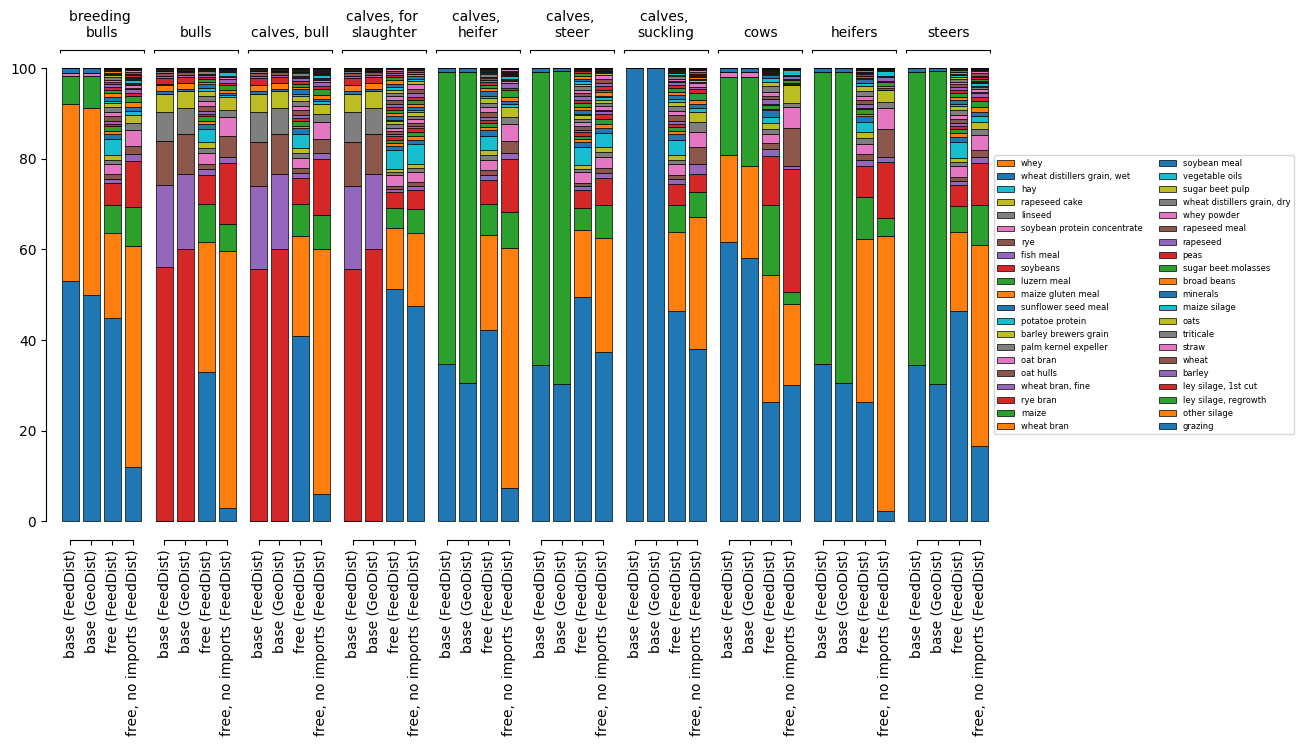

('cattle', 'beef', 'conventional', 'maize based')


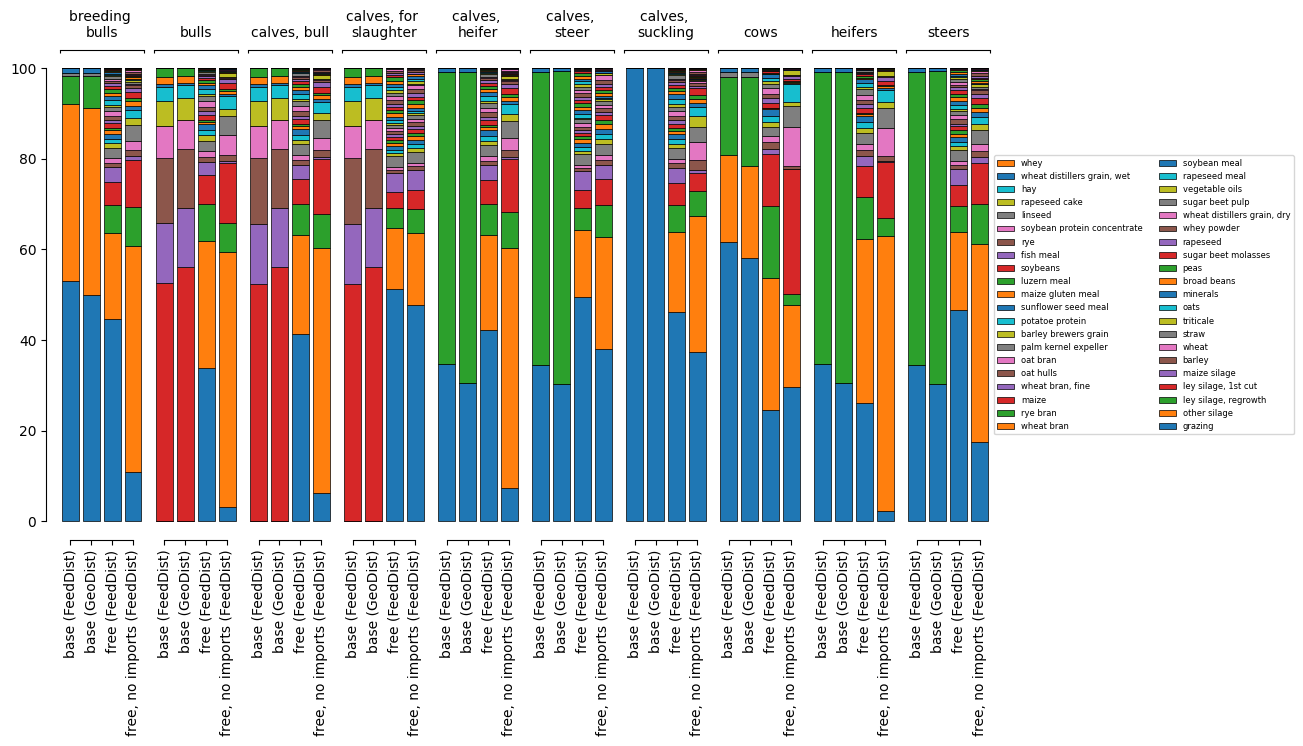

('cattle', 'beef', 'organic', 'ley based')


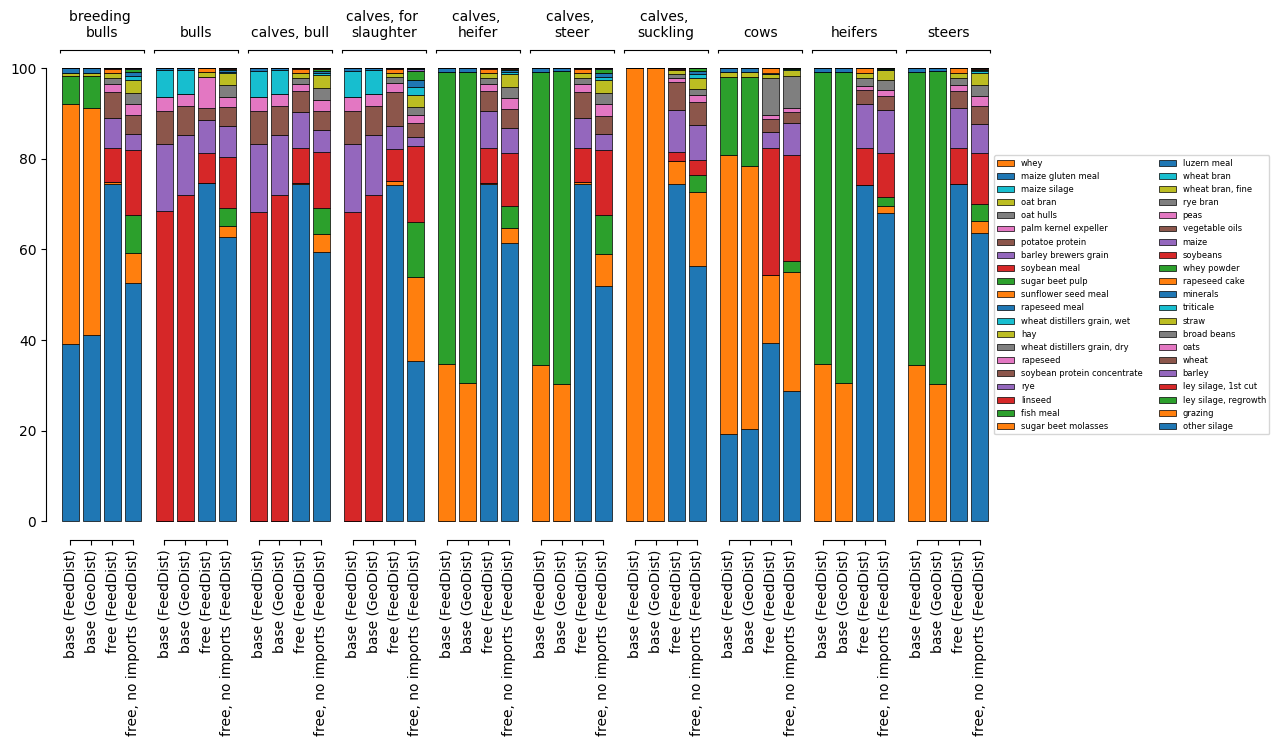

('cattle', 'dairy', 'conventional', 'ley based')


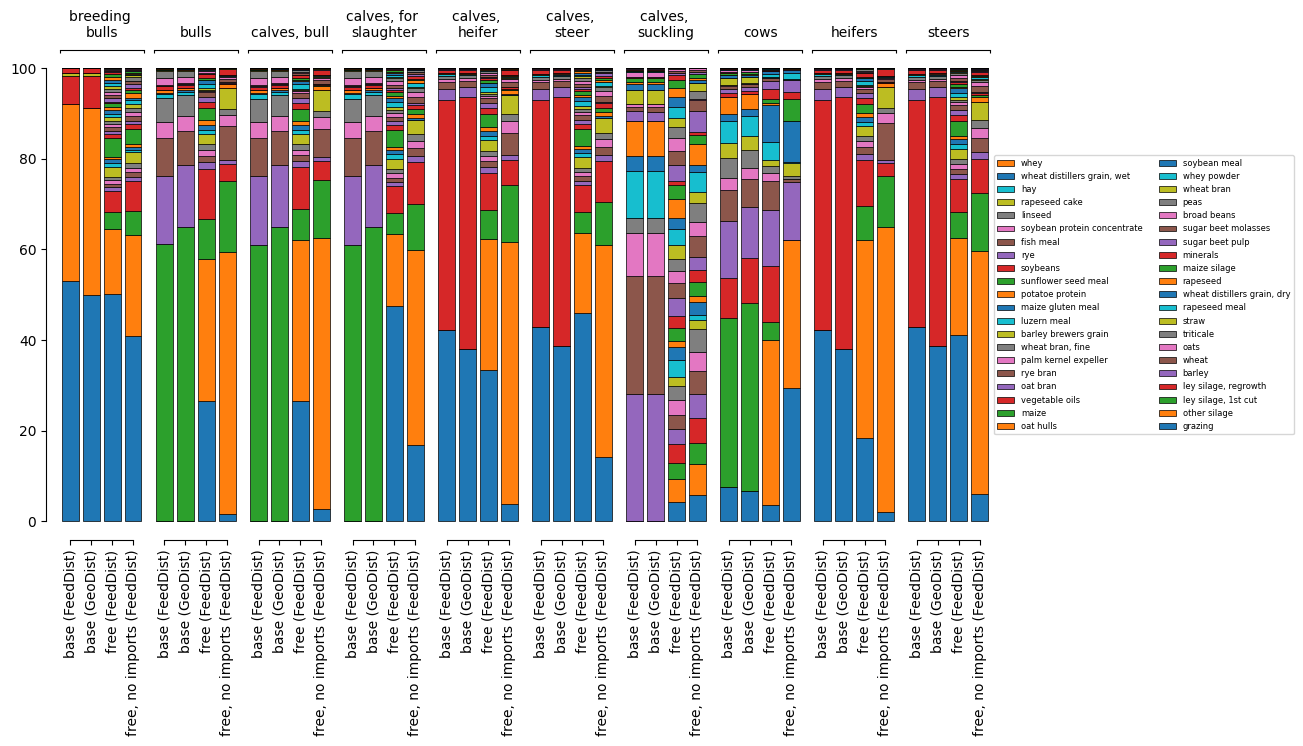

('cattle', 'dairy', 'conventional', 'maize based')


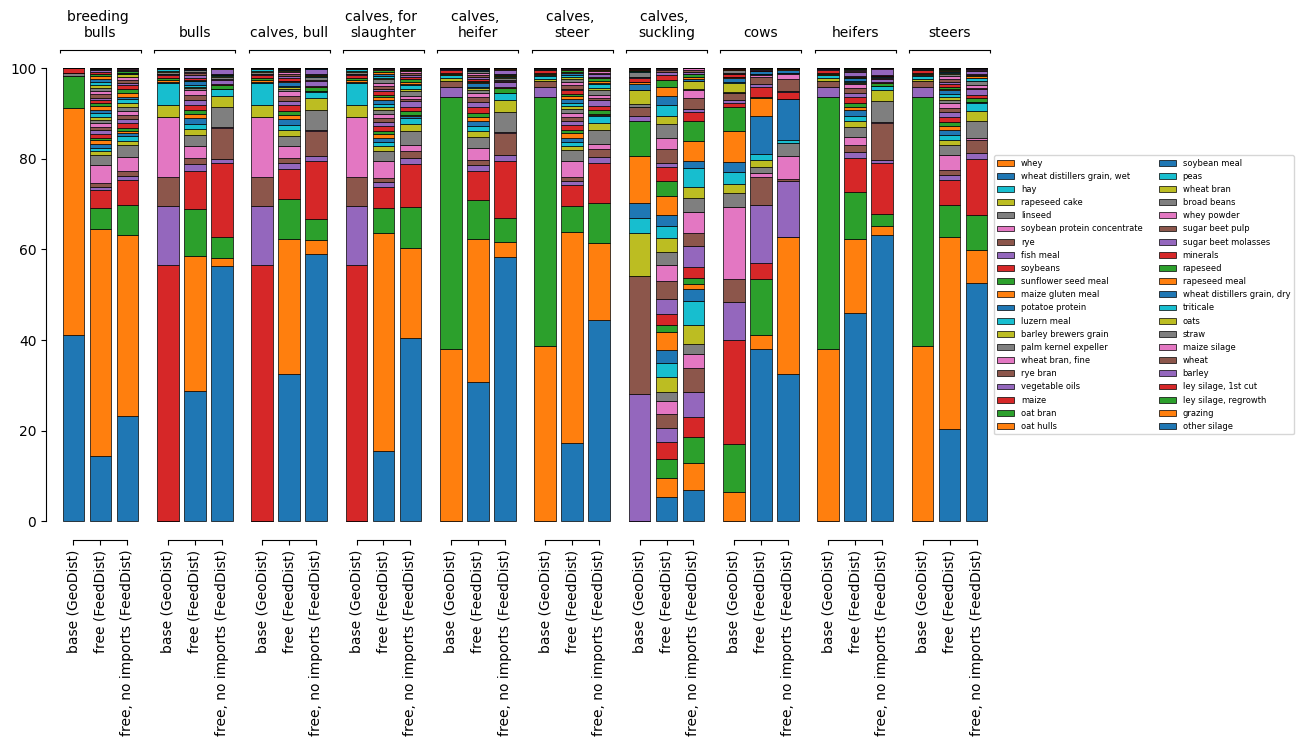

('cattle', 'dairy', 'organic', 'ley based')


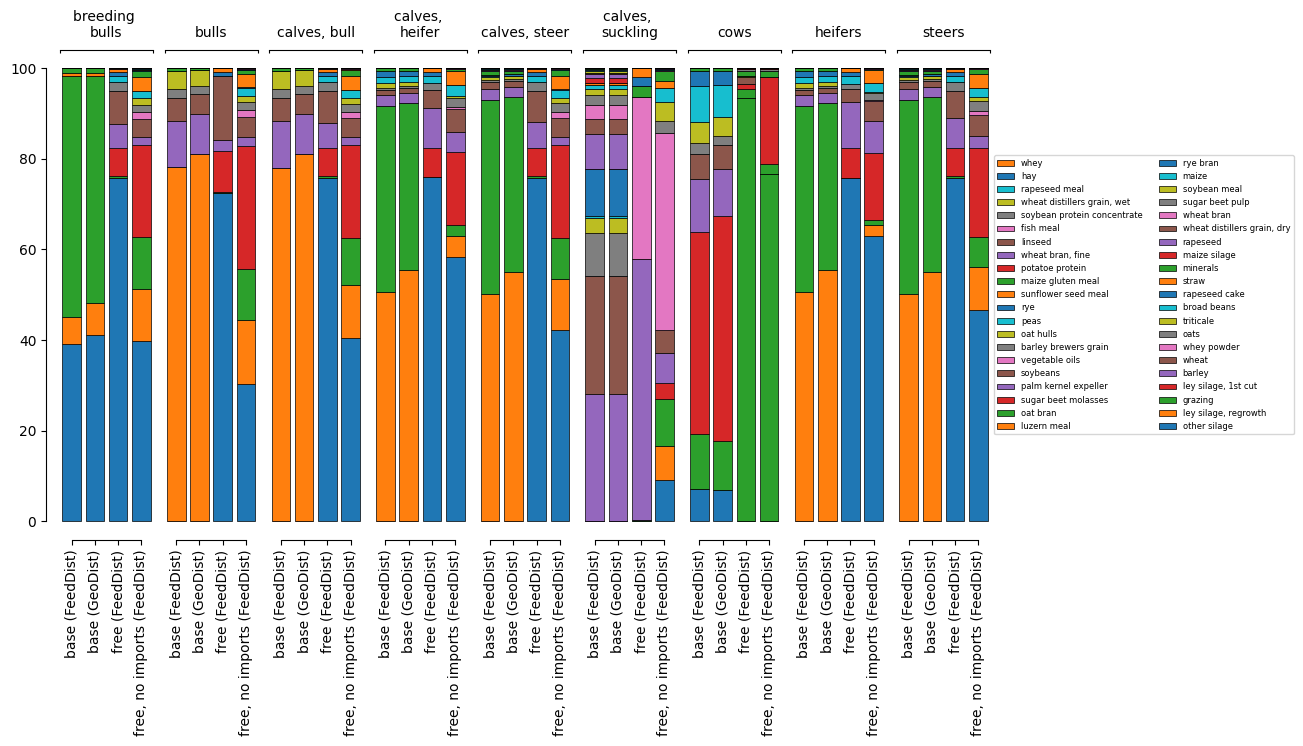

In [9]:
rations = (
    session.get_attr('a','feed.consumption',['species','breed','prod_system','sub_system','animal','feed'])
    .stack(['species','breed','prod_system','sub_system','animal'])
    .fillna(0).div(
        session.get_attr('a','heads',['species','breed','prod_system','sub_system','animal'])
        .stack(['species','breed','prod_system','sub_system','animal']),
        axis = 0
    )
    .stack().droplevel('year').unstack(['scn'])
    .groupby(['species','breed','prod_system','sub_system','animal']).apply(lambda x: x/x.sum()*100)
    .droplevel([0,1,2,3,4])
    .stack().unstack('feed')
)

for idx in rations.loc[['cattle']].index.droplevel(['animal','scn']).unique():
    print(idx)
    fig,ax = plt.subplots(figsize=(12,6))
    cm.plot.bar(
        rations.loc[idx],
        group_levels='animal',
        sort_categories=True,
        ax=ax
    )
    ax.legend(ncol=2, reverse=True, fontsize=6,
              loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

In [24]:
pd.concat([d1,d2], axis=1).fillna(0)

prod_system                                    conventional                    \
                                         cereal by-products dairy by-products   
scn                         year species                                        
base (GeoDist)              2020 cattle        6.969177e+07      0.000000e+00   
                                 horses        1.651374e+07      0.000000e+00   
                                 pigs          1.903708e+08      4.715791e+08   
                                 poultry       1.618700e+07      0.000000e+00   
                                 sheep         6.756214e+05      0.000000e+00   
base (FeedDist)             2020 cattle        6.646507e+07      0.000000e+00   
                                 horses        1.716317e+07      0.000000e+00   
                                 pigs          1.902065e+08      4.671921e+08   
                                 poultry       1.618700e+07      0.000000e+00   
                                 sheep         7.065581e+05      0.000000e+00   
free (FeedDist)             2020 cattle        2.411404e+08      4.601153e+08   
                                 horses        1.861654e+07      0.000000e+00   
                                 pigs          1.902065e+08      4.671921e+08   
                                 poultry       1.618700e+07      0.000000e+00   
                                 sheep         7.109478e+05      0.000000e+00   
free, no imports (FeedDist) 2020 cattle        2.207339e+08      4.736357e+08   
                                 horses        1.817885e+07      0.000000e+00   
                                 pigs          1.902065e+08      4.671921e+08   
                                 poultry       1.618700e+07      0.000000e+00   
                                 sheep         7.067351e+05      0.000000e+00   

prod_system                                                           organic  \
                                         other by-products cereal by-products   
scn                         year species                                        
base (GeoDist)              2020 cattle       1.618290e+08       6.437216e+04   
                                 horses       1.302510e+07       5.286791e-01   
                                 pigs         7.920357e+07       0.000000e+00   
                                 poultry      1.657432e+08       4.789247e+05   
                                 sheep        2.118108e+06       1.933592e+05   
base (FeedDist)             2020 cattle       1.542099e+08       6.593240e+04   
                                 horses       1.350629e+07       4.821992e-01   
                                 pigs         7.923489e+07       0.000000e+00   
                                 poultry      1.657432e+08       4.789247e+05   
                                 sheep        2.214440e+06       2.140411e+05   
free (FeedDist)             2020 cattle       2.523863e+08       1.948955e+07   
                                 horses       1.465000e+07       0.000000e+00   
                                 pigs         7.923489e+07       0.000000e+00   
                                 poultry      1.657432e+08       4.789240e+05   
                                 sheep        2.228198e+06       1.878192e+05   
free, no imports (FeedDist) 2020 cattle       1.119437e+08       1.313032e+07   
                                 horses       1.430557e+07       0.000000e+00   
                                 pigs         7.923489e+07       0.000000e+00   
                                 poultry      1.657432e+08       4.789247e+05   
                                 sheep        2.214995e+06       1.878192e+05   

prod_system                                                                   \
                                         dairy by-products other by-products   
scn                         year species                                       
base (GeoDist)              2020

In [33]:
d_frac.droplevel(0, axis=1)

prod_system                                    conventional                    \
                                         cereal by-products dairy by-products   
scn                         year species                                        
base (GeoDist)              2020 cattle            0.016861          0.000000   
                                 horses            0.013262          0.000000   
                                 pigs              0.130106          0.322293   
                                 poultry           0.021074          0.000000   
                                 sheep             0.003677          0.000000   
base (FeedDist)             2020 cattle            0.016682          0.000000   
                                 horses            0.014027          0.000000   
                                 pigs              0.130353          0.320177   
                                 poultry           0.021074          0.000000   
                                 sheep             0.003902          0.000000   
free (FeedDist)             2020 cattle            0.052504          0.100182   
                                 horses            0.015145          0.000000   
                                 pigs              0.130353          0.320177   
                                 poultry           0.021074          0.000000   
                                 sheep             0.003897          0.000000   
free, no imports (FeedDist) 2020 cattle            0.048232          0.103493   
                                 horses            0.014809          0.000000   
                                 pigs              0.130353          0.320177   
                                 poultry           0.021074          0.000000   
                                 sheep             0.003867          0.000000   

prod_system                                                           \
                                         other by-products    barley   
scn                         year species                               
base (GeoDist)              2020 cattle           0.039153  0.074238   
                                 horses           0.010460  0.000952   
                                 pigs             0.054130  0.177422   
                                 poultry          0.215783  0.009967   
                                 sheep            0.011528  0.006320   
base (FeedDist)             2020 cattle           0.038706  0.085678   
                                 horses           0.011038  0.001007   
                                 pigs             0.054301  0.178027   
                                 poultry          0.215783  0.009967   
                                 sheep            0.012231  0.006707   
free (FeedDist)             2020 cattle           0.054953  0.066085   
                                 horses           0.011918  0.001087   
                                 pigs             0.054301  0.178027   
                                 poultry          0.215783  0.009967   
                                 sheep            0.012213  0.006697   
free, no imports (FeedDist) 2020 cattle           0.024461  0.066300   
                                 horses           0.011654  0.001063   
                                 pigs             0.054301  0.178027   
                                 poultry          0.215783  0.009967   
                                 sheep            0.012119  0.006646   

prod_system                                                               \
                                         broad beans    fodder   grazing   
scn                         year species                                   
base (GeoDist)              2020 cattle     0.003027  0.546193  0.187231   
                                 horses     0.000000  0.734662  0.226333   
                                 pigs       0.037432  0.000000  0.000000   
                       

organic


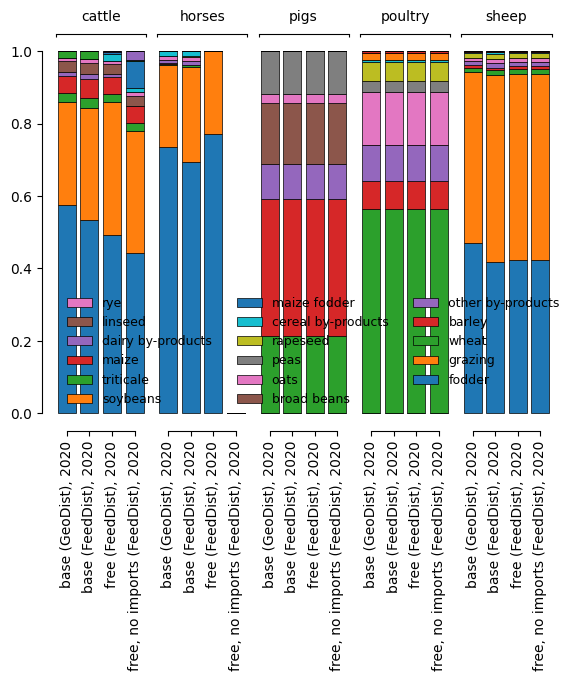

conventional


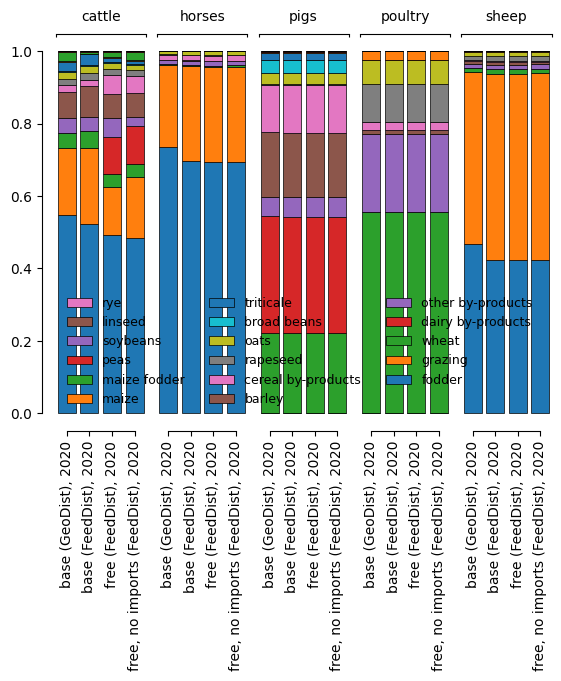

In [34]:
d1 = (
    session.get_attr('a','feed.by_product_demand',{'prod_system':None,'species':None,'by_prod':'by_prod_group'})
    .stack('species')
)
d2 = (
    session.get_attr('a','feed.crop_product_demand',{'prod_system':None,'species':None,'crop_prod':None})
    .stack('species')
)
d = pd.concat([d1,d2], axis=1).fillna(0)
d_frac = d.T.groupby('prod_system').apply(lambda x: x/x.sum()).droplevel(0).T

print('organic')
cm.plot.bar(
    d_frac.loc[:,'organic'],
    group_levels='species',
    sort_categories=True
)
plt.show()
print('conventional')
cm.plot.bar(
    d_frac.loc[:,'conventional'],
    group_levels='species',
    sort_categories=True
)
plt.show()



# cm.plot.bar(
#     d,
#     group_levels='species'
# )
# plt.show()

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

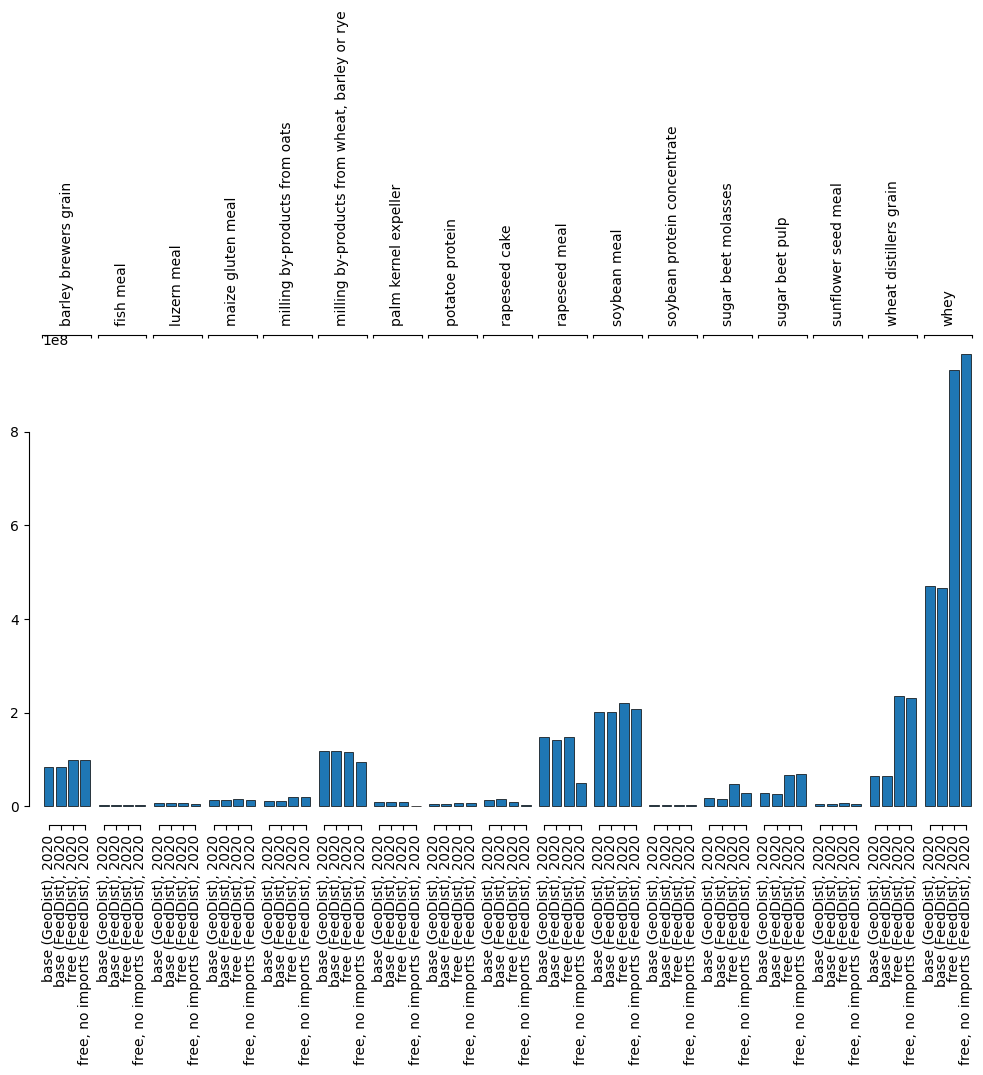

In [35]:
d=session.get_attr('a','feed.by_prod','by_prod').stack()

fig,ax = plt.subplots(figsize=(12,6))
cm.plot.bar(
    d,
    group_levels='by_prod',
    grouplabels_vertical=True,
    ax=ax
)

# Imported crop-/by-products

In [42]:
d = (
    session.get_attr('a','feed.crop_product_demand', ['origin','species','prod_system','crop_prod'])
    .loc[('base (GeoDist)','2020'),'imported']
    # .drop('cattle', level='species')
    .groupby(['prod_system','crop_prod']).sum()
)/1000
d.to_clipboard()
d

prod_system   crop_prod
conventional  linseed        277.741519
              maize        15355.000467
              soybeans      1477.171055
organic       linseed          0.493379
              maize          216.593696
              soybeans      1256.397073
Name: (base (GeoDist), 2020), dtype: float64

In [43]:
d = (
    session.get_attr('a','feed.by_product_demand', ['species','prod_system','by_prod'])
    .loc[('base (GeoDist)','2020')]
    # .drop('cattle', level='species')
    .groupby(['prod_system','by_prod']).sum()
)/1000
d = (
    d.mul(1 - feed_mgmt_geo.par.get('share_domestic', **d.index.to_frame().to_dict('list'))/100)
    .replace({0:np.nan}).dropna(how='all')
)
d.to_clipboard()
d

prod_system   by_prod                                      
conventional  fish meal                                          3368.041980
              luzern meal                                        7313.040132
              maize gluten meal                                 13440.928580
              milling by-products from wheat, barley or rye     23739.411004
              palm kernel expeller                               9172.447214
              rapeseed meal                                     85544.916257
              soybean meal                                     199455.791268
              soybean protein concentrate                        2287.204623
              sunflower seed meal                                6020.223285
organic       fish meal                                           115.478987
              luzern meal                                          22.372655
              maize gluten meal                                   479.938875
              mi

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

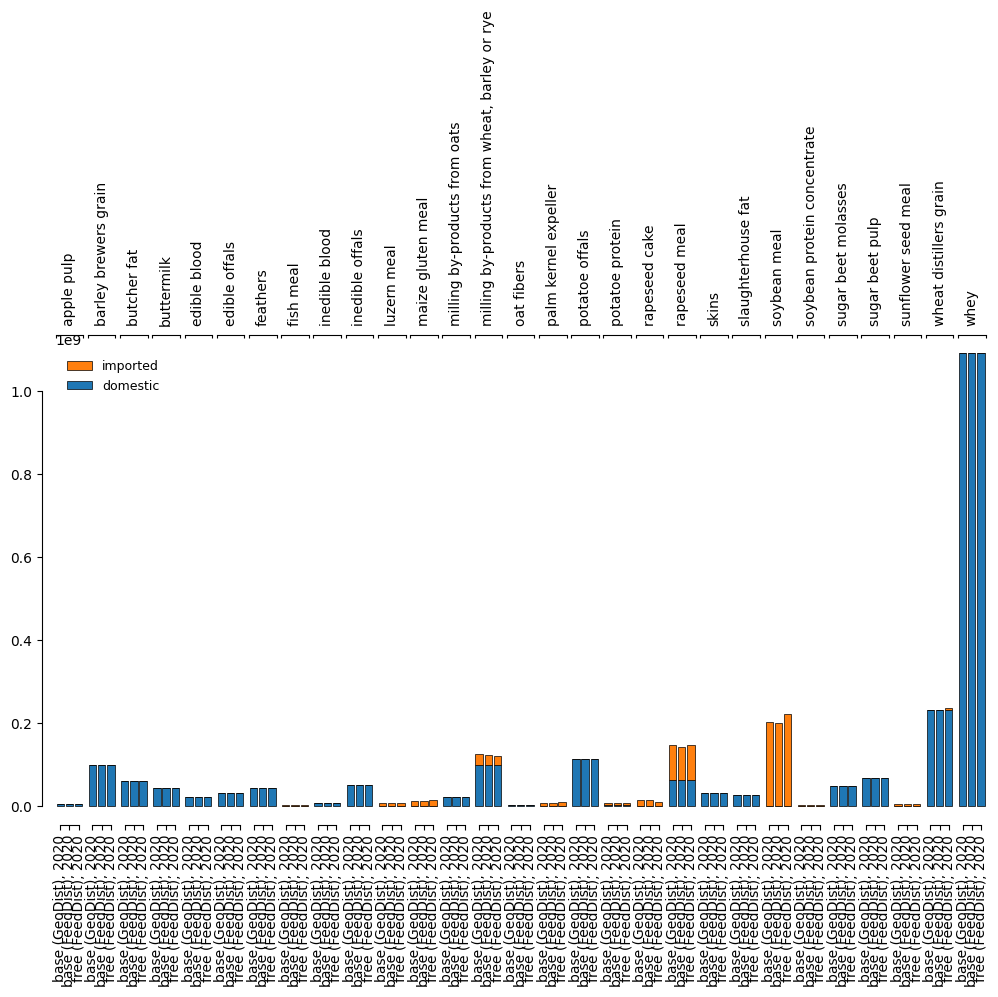

In [67]:
d=session.get_attr('d','by_products',['origin','by_prod']).stack()

fig,ax = plt.subplots(figsize=(12,6))
cm.plot.bar(
    d,
    group_levels='by_prod',
    grouplabels_vertical=True,
    ax=ax
)

(<Axes: >, [<Axes: label='inset_axes'>])

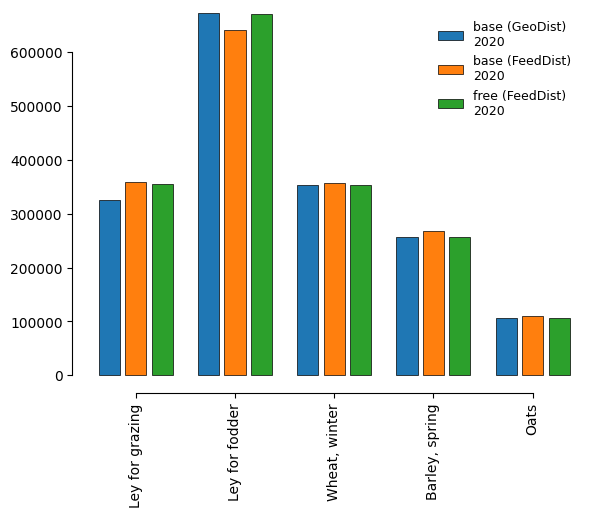

In [77]:
cm.plot.bar(
    session.get_attr('c','area','crop').loc[:,['Ley for grazing','Ley for fodder','Wheat, winter', 'Barley, spring', 'Oats']].T,
    stacked=False
)

In [10]:
pd.concat([
    session.get_attr('c','area','crop').loc[:,'Ley for grazing'],
    session.get_attr('r','x0_crops','crop').loc[:,'Ley for grazing']
])

scn        year
base_feed  2020    351711.146957
base_geo   2020    309243.856482
base_feed  2020    243941.736682
base_geo   2020    243941.736682
Name: Ley for grazing, dtype: float64

In [11]:
pd.concat([
    session.get_attr('c','area','crop').loc[:,'Semi-natural pastures'],
    session.get_attr('r','x0_crops','crop').loc[:,'Semi-natural pastures']
])

scn        year
base_feed  2020    454815.849248
base_geo   2020    373425.650649
base_feed  2020    445155.134909
base_geo   2020    370156.346072
Name: Semi-natural pastures, dtype: float64

In [12]:
rations#.loc[('cattle','dairy','cows')]

feed                                                               grazing  \
species breed prod_system  sub_system  animal         scn                    
cattle  beef  conventional ley based   breeding bulls base_feed  53.115209   
                                                      base_geo   50.052482   
                                       bulls          base_feed   0.000000   
                                                      base_geo    0.000000   
                                       calves, bull   base_feed   0.000000   
...                                                                    ...   
sheep   none  organic      winter lamb ewes           base_geo   55.686616   
                                       lambs          base_feed  46.083142   
                                                      base_geo   41.770329   
                                       rams           base_feed  60.075694   
                                                      base_geo   55.686616   

feed                                                             ley silage, regrowth  \
species breed prod_system  sub_system  animal         scn                               
cattle  beef  conventional ley based   breeding bulls base_feed              6.104350   
                                                      base_geo               7.017813   
                                       bulls          base_feed              0.000000   
                                                      base_geo               0.000000   
                                       calves, bull   base_feed              0.000000   
...                                                                               ...   
sheep   none  organic      winter lamb ewes           base_geo              29.113885   
                                       lambs          base_feed             34.151422   
                                                      base_geo              37.161189   
                                       rams           base_feed             26.163337   
                                                      base_geo              29.113885   

feed                                                             minerals  \
species breed prod_system  sub_system  animal         scn                   
cattle  beef  conventional ley based   breeding bulls base_feed  1.108507   
                                                      base_geo   1.065907   
                                       bulls          base_feed  0.655516   
                                                      base_geo   0.594528   
                                       calves, bull   base_feed  0.659406   
...                                                                   ...   
sheep   none  organic      winter lamb ewes           base_geo   0.000000   
                                       lambs          base_feed  0.000000   
                                                      base_geo   0.000000   
                                       rams           base_feed  0.000000   
                                                      base_geo   0.000000   

feed                                                             other silage  \
species breed prod_system  sub_system  animal         scn                       
cattle  beef  conventional ley based   breeding bulls base_feed     39.035705   
                                                      base_geo      41.192418   
                                       bulls          base_feed      0.000000   
                                                      base_geo       0.000000   
                                       calves, bull   base_feed      0.000000   
...                                                                       ...   
sheep   none  organic      winter lamb ewes           base_geo       0.000000   
                                       lambs          base_feed      0.000000   
               

In [13]:
d = session.get_attr('a', 'feed.consumption',['species','feed']).stack('feed').fillna(0)
((d.loc['base_feed'] - d.loc['base_geo'])/d.loc['base_geo'] * 100).fillna(0).style.format(precision=2)

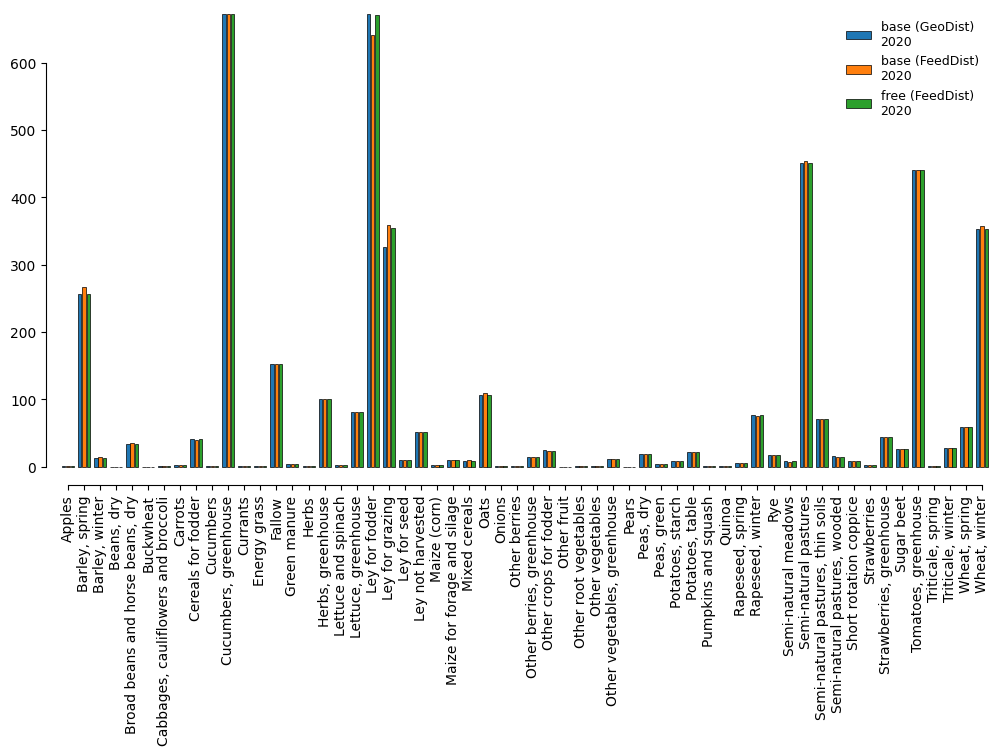

crop
Apples                                  0.02
Barley, spring                          3.82
Barley, winter                          7.68
Beans, dry                             -0.00
Broad beans and horse beans, dry        5.36
Buckwheat                              20.91
Cabbages, cauliflowers and broccoli    -0.06
Carrots                                 0.01
Cereals for fodder                     -4.05
Cucumbers                               0.04
Cucumbers, greenhouse                  -0.00
Currants                                0.01
Energy grass                            0.02
Fallow                                 -0.02
Green manure                            0.30
Herbs                                  -0.05
Herbs, greenhouse                      -0.00
Lettuce and spinach                     0.01
Lettuce, greenhouse                    -0.01
Ley for fodder                         -4.63
Ley for grazing                        10.11
Ley for seed                            0.23
Ley n

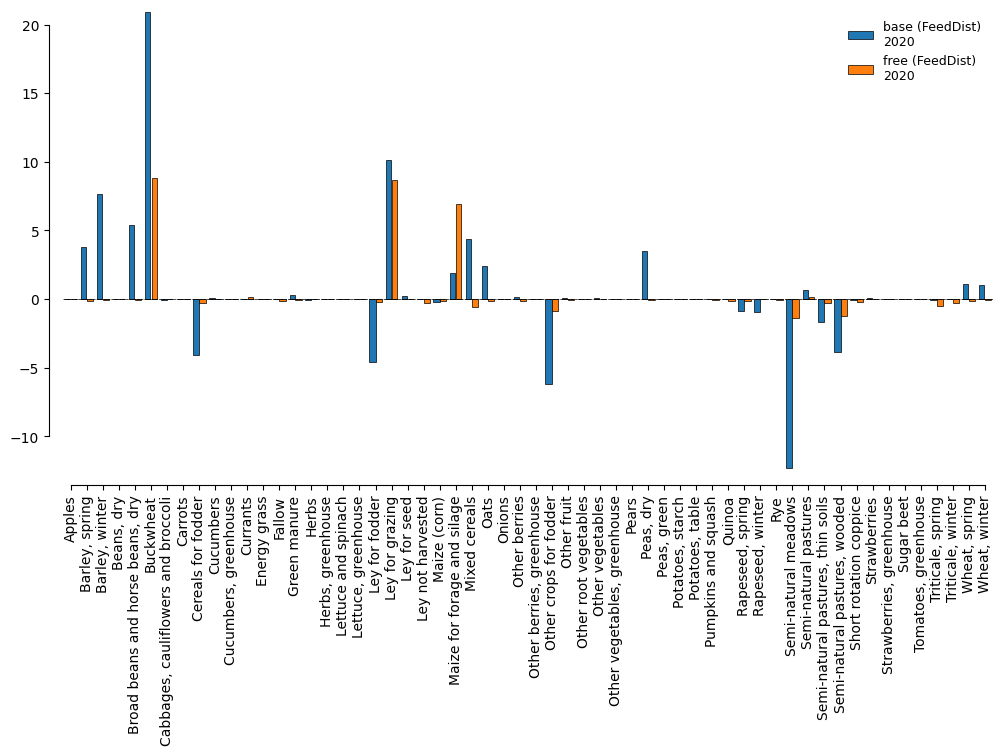

In [17]:
d = session.get_attr('c','area','crop').T / 1_000

fig,ax = plt.subplots(figsize=(12,6))
cm.plot.bar(
    d,
    stacked=False,
    ax=ax
)
plt.show()

fig,ax = plt.subplots(figsize=(12,6))
fig,ax = cm.plot.bar(
    d.iloc[:,1:].sub(d.iloc[:,0], axis=0).div(d.iloc[:,0], axis=0)*100,
    stacked=False,
    ax=ax
)

display(((d.iloc[:,1] - d.iloc[:,0]) / d.iloc[:,0] * 100).round(2))

(<Axes: >, [<Axes: label='inset_axes'>])

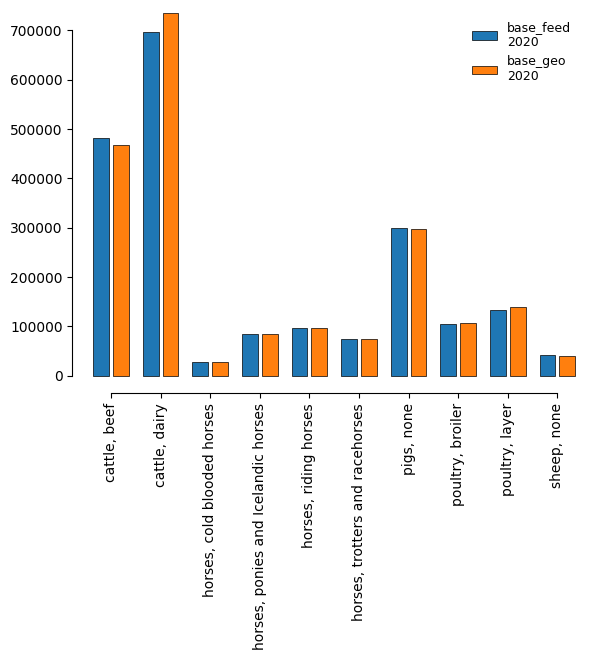

In [15]:
d = cm.impact.get_LSU(session, ['species','breed']).T

cm.plot.bar(
    d,
    stacked=False
)